# Práctica 04: Manejo de Mapas de Calor (Heatmaps) Georeferenciales en el Análisis EDA

**Programa de Estudios:** Ingeniería en Desarrollo y Gestión de Software  
**Asignatura:** Extracción de Conocimiento en Base de Datos  
**Unidad II:** Preparación de los Datos  
**Estudiante:** Farias Leyva Al  
**Matrícula:** 230389  
**Periodo:** Mayo - Agosto 2026  

## Objetivo
Realizar un análisis exploratorio de datos sobre el conjunto DonorsChoose y aplicar mapas georreferenciados para identificar la concentración de donadores por estado y ciudad en Estados Unidos.


## 1. Instalación e importación de librerías

> Ejecuta esta celda solo la primera vez.  
> Coloca este notebook en una carpeta que tenga otra carpeta llamada `datasets` con los archivos CSV.


In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn plotly folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [folium]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium
from folium import plugins

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Carga de los datasets

In [4]:
path = "./datasets/"

donors_df = pd.read_csv(path + "Donors.csv")
donations_df = pd.read_csv(path + "Donations.csv")
teachers_df = pd.read_csv(path + "Teachers.csv")
schools_df = pd.read_csv(path + "Schools.csv")
resources_df = pd.read_csv(path + "Resources.csv")
projects_df = pd.read_csv(path + "Projects.csv")
zip_df = pd.read_csv(path + "zip_codes_states.csv")

print("Datasets cargados correctamente.")

Datasets cargados correctamente.


In [6]:
resumen = pd.DataFrame({
    "Dataset": ["Donors", "Donations", "Teachers", "Schools", "Resources", "Projects", "Zip codes"],
    "Filas": [len(donors_df), len(donations_df), len(teachers_df), len(schools_df),
              len(resources_df), len(projects_df), len(zip_df)],
    "Columnas": [donors_df.shape[1], donations_df.shape[1], teachers_df.shape[1], schools_df.shape[1],
                 resources_df.shape[1], projects_df.shape[1], zip_df.shape[1]]
})
resumen

,Dataset,Filas,Columnas
0,Donors,200,5
1,Donations,200,7
2,Teachers,200,3
3,Schools,200,9
4,Resources,250,5
5,Projects,150,15
6,Zip codes,42741,6


## 3. Exploración de donadores

Primero se revisan los registros disponibles y se identifican los estados y ciudades con mayor número de donadores.


In [7]:
donors_df.head()

,Donor ID,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,bdd640fb06671ad11c80317fa3b1799d,San Francisco,California,Yes,114
1,8b9d2434e465e150bd9c66b3ad3c2d6d,San Jose,California,Yes,105
2,9a1de644815ef6d13b8faa1837f8a88b,San Francisco,California,No,728
3,72ff5d2a386ecbe06b65a6a48b8148f6,Houston,Texas,No,173
4,47229389571aa8766c307511b2b9437a,San Diego,California,Yes,399


In [8]:
print("Valores nulos por columna:")
donors_df.isnull().sum()

Valores nulos por columna:


Donor ID            0
Donor City          0
Donor State         0
Donor Is Teacher    0
Donor Zip           0
dtype: int64

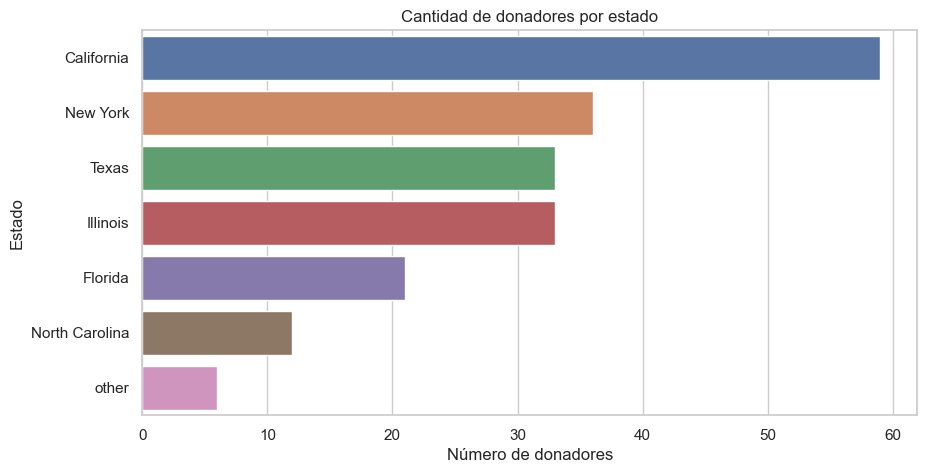

,Estado,Cantidad de donadores
0,California,59
1,New York,36
2,Texas,33
3,Illinois,33
4,Florida,21
5,North Carolina,12
6,other,6


In [9]:
donors_by_state = donors_df["Donor State"].value_counts().reset_index()
donors_by_state.columns = ["Estado", "Cantidad de donadores"]

plt.figure(figsize=(10, 5))
sns.barplot(data=donors_by_state, x="Cantidad de donadores", y="Estado", hue="Estado", legend=False)
plt.title("Cantidad de donadores por estado")
plt.xlabel("Número de donadores")
plt.ylabel("Estado")
plt.show()

donors_by_state

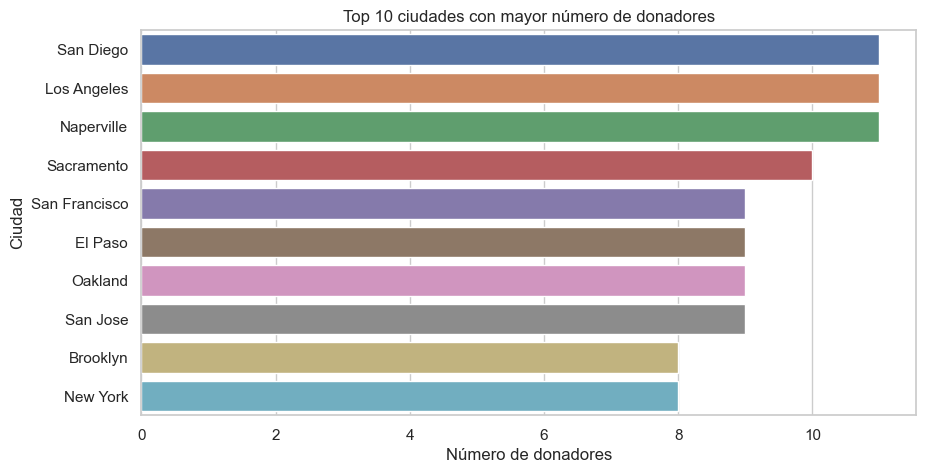

,Ciudad,Cantidad de donadores
0,San Diego,11
1,Los Angeles,11
2,Naperville,11
3,Sacramento,10
4,San Francisco,9
5,El Paso,9
6,Oakland,9
7,San Jose,9
8,Brooklyn,8
9,New York,8


In [10]:
top_cities = donors_df["Donor City"].value_counts().head(10).reset_index()
top_cities.columns = ["Ciudad", "Cantidad de donadores"]

plt.figure(figsize=(10, 5))
sns.barplot(data=top_cities, x="Cantidad de donadores", y="Ciudad", hue="Ciudad", legend=False)
plt.title("Top 10 ciudades con mayor número de donadores")
plt.xlabel("Número de donadores")
plt.ylabel("Ciudad")
plt.show()

top_cities

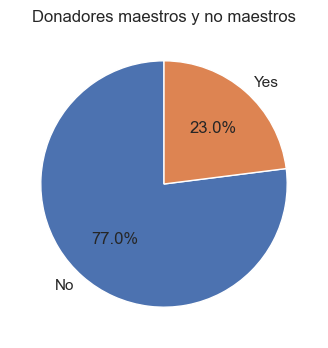

In [11]:
teacher_counts = donors_df["Donor Is Teacher"].value_counts().reset_index()
teacher_counts.columns = ["Es maestro", "Cantidad"]

plt.figure(figsize=(6, 4))
plt.pie(teacher_counts["Cantidad"], labels=teacher_counts["Es maestro"], autopct="%1.1f%%", startangle=90)
plt.title("Donadores maestros y no maestros")
plt.show()

## 4. Mapa coroplético por estado

Este mapa muestra la cantidad de donadores registrados en cada estado de Estados Unidos.


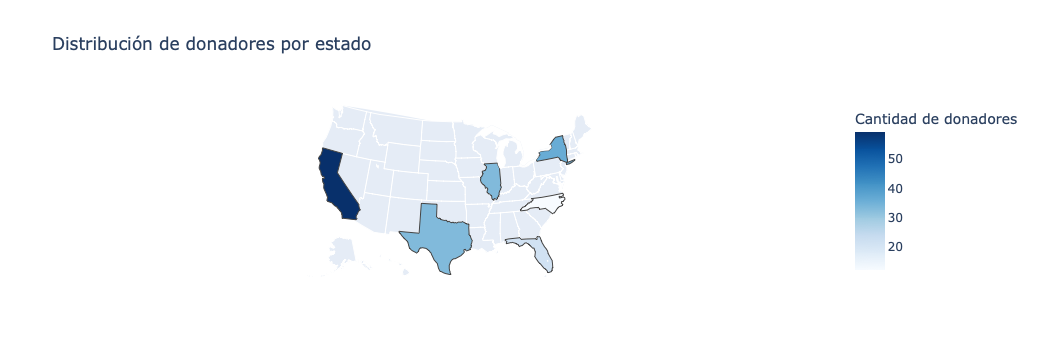

In [12]:
state_to_code = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
    "Colorado":"CO","Connecticut":"CT","Delaware":"DE","District of Columbia":"DC",
    "Florida":"FL","Georgia":"GA","Hawaii":"HI","Idaho":"ID","Illinois":"IL",
    "Indiana":"IN","Iowa":"IA","Kansas":"KS","Kentucky":"KY","Louisiana":"LA",
    "Maine":"ME","Maryland":"MD","Massachusetts":"MA","Michigan":"MI","Minnesota":"MN",
    "Mississippi":"MS","Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV",
    "New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM","New York":"NY",
    "North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK",
    "Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC",
    "South Dakota":"SD","Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT",
    "Virginia":"VA","Washington":"WA","West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY"
}

map_states = donors_by_state.copy()
map_states["Código"] = map_states["Estado"].map(state_to_code)
map_states = map_states.dropna(subset=["Código"])

fig = px.choropleth(
    map_states,
    locations="Código",
    locationmode="USA-states",
    color="Cantidad de donadores",
    hover_name="Estado",
    scope="usa",
    color_continuous_scale="Blues",
    title="Distribución de donadores por estado"
)
fig.show()

## 5. Preparación de coordenadas geográficas

El dataset de donadores tiene ciudad y estado, pero no latitud y longitud. Por eso se usa `zip_codes_states.csv` para asociar cada ciudad con coordenadas aproximadas.


In [13]:
state_to_abbr = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
    "Colorado":"CO","Connecticut":"CT","Delaware":"DE","District of Columbia":"DC",
    "Florida":"FL","Georgia":"GA","Hawaii":"HI","Idaho":"ID","Illinois":"IL",
    "Indiana":"IN","Iowa":"IA","Kansas":"KS","Kentucky":"KY","Louisiana":"LA",
    "Maine":"ME","Maryland":"MD","Massachusetts":"MA","Michigan":"MI","Minnesota":"MN",
    "Mississippi":"MS","Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV",
    "New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM","New York":"NY",
    "North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK",
    "Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC",
    "South Dakota":"SD","Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT",
    "Virginia":"VA","Washington":"WA","West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY"
}

city_counts = (
    donors_df.groupby(["Donor State", "Donor City"])
    .size()
    .reset_index(name="Cantidad")
)

city_counts["state"] = city_counts["Donor State"].map(state_to_abbr)
city_counts["city"] = city_counts["Donor City"].str.strip().str.lower()

coords = (
    zip_df[["city", "state", "latitude", "longitude"]]
    .dropna()
    .assign(city=lambda x: x["city"].str.strip().str.lower())
    .groupby(["city", "state"], as_index=False)[["latitude", "longitude"]]
    .mean()
)

geo_donors = city_counts.merge(coords, on=["city", "state"], how="left")
geo_donors = geo_donors.dropna(subset=["latitude", "longitude"])

print(f"Ciudades con coordenadas encontradas: {len(geo_donors)} de {len(city_counts)}")
geo_donors.head()

Ciudades con coordenadas encontradas: 31 de 35


,Donor State,Donor City,Cantidad,state,city,latitude,longitude
0,California,Los Angeles,11,CA,los angeles,33.807944,-118.290623
1,California,Oakland,9,CA,oakland,37.756148,-122.128470
2,California,Sacramento,10,CA,sacramento,38.429643,-121.445187
3,California,San Diego,11,CA,san diego,32.894150,-116.994339
4,California,San Francisco,9,CA,san francisco,37.776269,-122.610509


## 6. Heatmap georreferenciado de todos los donadores

Las zonas con colores más intensos representan una mayor concentración de donadores.


In [14]:
usa_map = folium.Map(
    location=[39.5, -98.35],
    zoom_start=4,
    tiles="CartoDB positron"
)

heat_data = geo_donors[["latitude", "longitude", "Cantidad"]].values.tolist()

plugins.HeatMap(
    heat_data,
    radius=20,
    blur=15,
    min_opacity=0.4
).add_to(usa_map)

usa_map

## 7. Heatmap de California

California es el estado con más registros en esta muestra, por ello se analiza de forma individual.


In [15]:
california_geo = geo_donors[geo_donors["Donor State"] == "California"].copy()

california_map = folium.Map(
    location=[36.78, -119.42],
    zoom_start=6,
    tiles="CartoDB positron"
)

california_heat = california_geo[["latitude", "longitude", "Cantidad"]].values.tolist()

plugins.HeatMap(
    california_heat,
    radius=28,
    blur=18,
    min_opacity=0.4
).add_to(california_map)

for _, row in california_geo.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=4,
        popup=f"{row['Donor City']}: {row['Cantidad']} donadores",
        color="blue",
        fill=True
    ).add_to(california_map)

california_map

## 8. Exploración de donaciones

Se analizan los montos de donación y se compara si las aportaciones incluyeron una donación opcional.


In [16]:
donations_df.head()

,Project ID,Donation ID,Donor ID,Donation Included Optional Donation,Donation Amount,Donor Cart Sequence,Donation Received Date
0,a013ac6ededa4e161b3dbd5ce9a1fa6f,0f1259e0a18ff6b6b535106e122c9a56,17fc695a07a0ca6e0822e8f36c031199,No,2219.27,2,2016-06-10 07:17:42
1,b09b2a5cbadcc32ac1590f538a0f4efb,21df306f8a0b3c3336d8393a7c441fe7,366eb16f508ebad7b7c93acfe059a0ee,Yes,44.02,8,2017-04-06 13:12:06
2,5cec4eb5edd968311ca35cfb04fc6d82,5ab33edf6e595ed3a8b317fa18d0752b,aefcfad8efc89849b3aa7efe4458a885,Yes,112.07,11,2016-10-31 20:06:03
3,1064005c3985c3cf3f76be1d1efa2197,ccf3a17156dc8907ba6c34ab6712303a,b74d0fb132e706298fadc1a606cb0fb3,Yes,36.63,8,2015-05-24 13:11:17
4,5715bd6fa4161293c4c2e2e3444ea7c8,ec5b227cdfde4fbf3ff350bf766ecb15,3eabedcbbaa80dd488bd64072bcfbe01,No,129.84,2,2015-02-21 20:34:53


In [17]:
print("Monto total donado: $", round(donations_df["Donation Amount"].sum(), 2))
print("Monto promedio por donación: $", round(donations_df["Donation Amount"].mean(), 2))
print("Donación máxima: $", round(donations_df["Donation Amount"].max(), 2))

Monto total donado: $ 99688.98
Monto promedio por donación: $ 498.44
Donación máxima: $ 60000.0


In [18]:
optional_summary = (
    donations_df.groupby("Donation Included Optional Donation")["Donation Amount"]
    .agg(["count", "mean", "sum"])
    .reset_index()
)
optional_summary.columns = ["Donación opcional", "Cantidad", "Promedio", "Total"]
optional_summary

,Donación opcional,Cantidad,Promedio,Total
0,No,69,1082.818841,74714.50
1,Yes,131,190.644885,24974.48


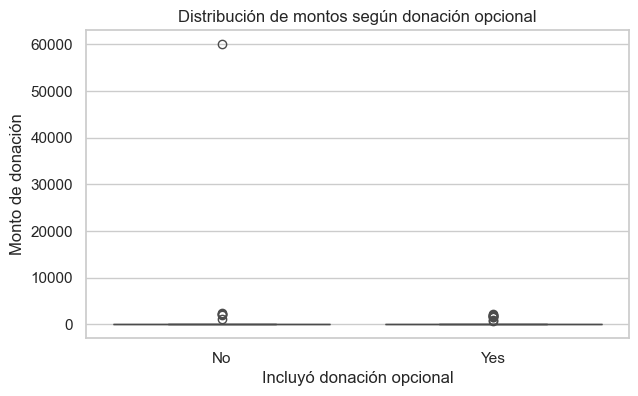

In [19]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=donations_df, x="Donation Included Optional Donation", y="Donation Amount")
plt.title("Distribución de montos según donación opcional")
plt.xlabel("Incluyó donación opcional")
plt.ylabel("Monto de donación")
plt.show()

## 9. Exploración de proyectos y escuelas

In [20]:
projects_df["Project Cost Num"] = (
    projects_df["Project Cost"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

projects_df["Project Posted Date"] = pd.to_datetime(projects_df["Project Posted Date"])
projects_df["Posted Year"] = projects_df["Project Posted Date"].dt.year

projects_df[["Project Title", "Project Cost", "Project Current Status", "Posted Year"]].head()

,Project Title,Project Cost,Project Current Status,Posted Year
0,Anti-Bullying Begins with Me,$231.17,Live,2014
1,Anti-Bullying Begins with Me,$317.67,Fully Funded,2014
2,Technology in the Classroom,$1339.63,Live,2015
3,Technology in the Classroom,$618.25,Fully Funded,2014
4,"Big Books, Flip Books",$420.67,Fully Funded,2013


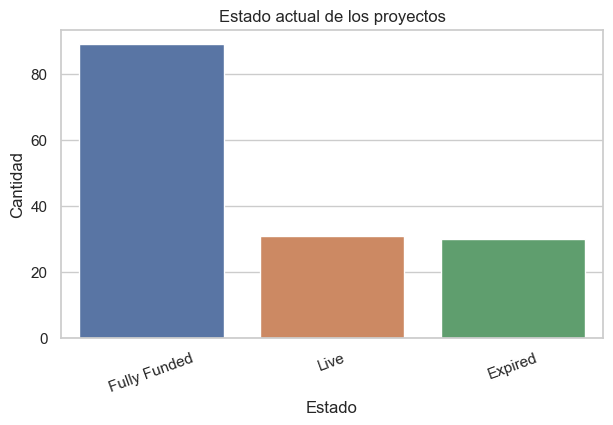

In [21]:
status_counts = projects_df["Project Current Status"].value_counts().reset_index()
status_counts.columns = ["Estado del proyecto", "Cantidad"]

plt.figure(figsize=(7, 4))
sns.barplot(data=status_counts, x="Estado del proyecto", y="Cantidad", hue="Estado del proyecto", legend=False)
plt.title("Estado actual de los proyectos")
plt.xlabel("Estado")
plt.ylabel("Cantidad")
plt.xticks(rotation=20)
plt.show()

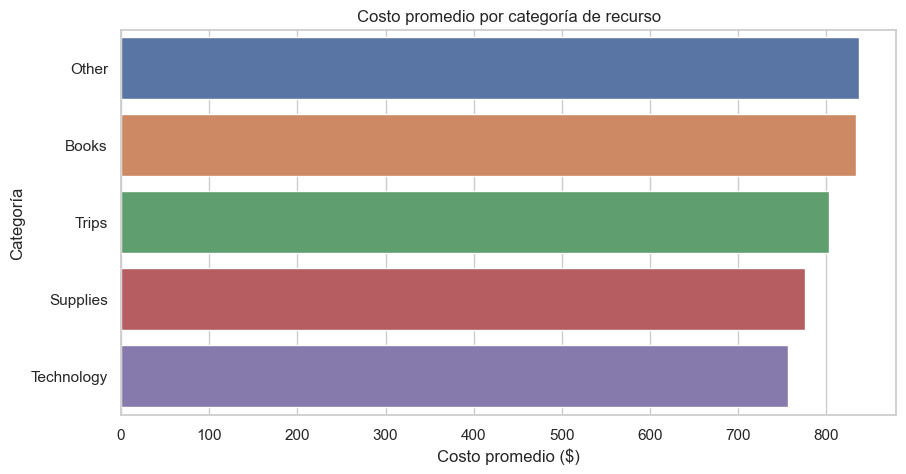

In [22]:
cost_by_resource = (
    projects_df.groupby("Project Resource Category")["Project Cost Num"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=cost_by_resource, x="Project Cost Num", y="Project Resource Category", hue="Project Resource Category", legend=False)
plt.title("Costo promedio por categoría de recurso")
plt.xlabel("Costo promedio ($)")
plt.ylabel("Categoría")
plt.show()

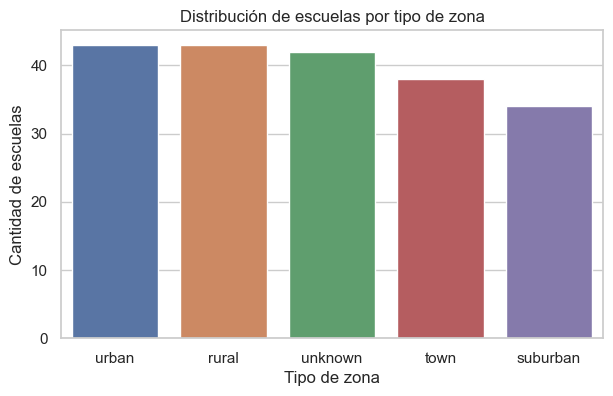

In [23]:
metro_counts = schools_df["School Metro Type"].value_counts().reset_index()
metro_counts.columns = ["Tipo de zona", "Cantidad"]

plt.figure(figsize=(7, 4))
sns.barplot(data=metro_counts, x="Tipo de zona", y="Cantidad", hue="Tipo de zona", legend=False)
plt.title("Distribución de escuelas por tipo de zona")
plt.xlabel("Tipo de zona")
plt.ylabel("Cantidad de escuelas")
plt.show()

## 10. Conclusiones

- California concentra la mayor cantidad de donadores dentro de la muestra analizada.
- Los mapas de calor permiten identificar visualmente las zonas urbanas donde se agrupan más donadores.
- La combinación de ciudad, estado, latitud y longitud permite convertir datos tabulares en información geográfica útil.
- El análisis de donaciones ayuda a observar los montos aportados y las diferencias relacionadas con las donaciones opcionales.
- El análisis exploratorio facilita detectar patrones antes de aplicar modelos más avanzados de minería de datos.
